### Porcentaje de puntos evaluados con reordenaciones

In [8]:
cesga = False

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path


def plot_pruning_points(csv_path: str, save: bool = False) -> None:
    df = pd.read_csv(csv_path)
    dataset_name = Path(csv_path).stem

    # Para cada hoja solo nos quedamos con la clave elegida (mejor poda)
    best = df.loc[df.groupby(['leaf', 'kernel', 'mode', 'radius'])['count'].idxmin()].copy()
    best['pruned'] = best['total'] - best['count']

    # Agregamos por radio y kernel: suma de puntos totales y puntos evaluados
    agg = (
        best.groupby(['mode', 'kernel', 'radius'])
        .agg(total_pts=('total', 'sum'), evaluated_pts=('count', 'sum'))
        .reset_index()
    )
    agg['pct_pruned'] = (1 - agg['evaluated_pts'] / agg['total_pts']) * 100

    modes = agg['mode'].unique()
    kernels = sorted(agg['kernel'].unique())
    radii = sorted(agg['radius'].unique())

    for mode in modes:
        df_mode = agg[agg['mode'] == mode]

        n_kernels = len(kernels)
        n_radii   = len(radii)
        group_width = 0.8
        bar_width   = group_width / (n_radii * 2)   # total + evaluated por radio

        x = np.arange(n_kernels)
        colors_total = plt.cm.Blues(np.linspace(0.4, 0.8, n_radii))
        colors_eval  = plt.cm.Oranges(np.linspace(0.4, 0.8, n_radii))

        fig, ax = plt.subplots(figsize=(max(10, n_kernels * 3), 6))

        for ri, radius in enumerate(radii):
            df_r = df_mode[df_mode['radius'] == radius].set_index('kernel')

            offset_total = (ri * 2 - (n_radii - 1)) * bar_width - bar_width / 2
            offset_eval  = offset_total + bar_width

            totals     = [df_r.loc[k, 'total_pts']     if k in df_r.index else 0 for k in kernels]
            evaluated  = [df_r.loc[k, 'evaluated_pts'] if k in df_r.index else 0 for k in kernels]
            pcts       = [df_r.loc[k, 'pct_pruned']    if k in df_r.index else 0 for k in kernels]

            bars_t = ax.bar(x + offset_total, totals,    bar_width,
                            label=f'r={radius} total',
                            color=colors_total[ri], edgecolor='white', linewidth=0.5)
            bars_e = ax.bar(x + offset_eval,  evaluated, bar_width,
                            label=f'r={radius} evaluados',
                            color=colors_eval[ri],  edgecolor='white', linewidth=0.5)

            # Etiqueta % poda sobre la barra de evaluados
            for bar, pct in zip(bars_e, pcts):
                if pct > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() * 1.01,
                            f'{pct:.1f}%',
                            ha='center', va='bottom', fontsize=7, color='black')

        ax.set_xticks(x)
        ax.set_xticklabels([k.upper() for k in kernels], fontsize=11)
        ax.set_xlabel('Kernel', fontsize=12)
        ax.set_ylabel('Puntos', fontsize=12)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda val, _: f'{val/1e6:.1f}M' if val >= 1e6 else f'{val/1e3:.0f}K'))
        ax.set_title(
            f'Puntos totales vs evaluados con poda\n'
            f'Dataset: {dataset_name}   Modo: {mode}',
            fontsize=13, fontweight='bold')
        ax.legend(ncol=n_radii, fontsize=8, loc='upper right')
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)
        plt.show()
        if (save):
            out_path = Path(csv_path).parent / f'{dataset_name}_{mode}_pruning_points.png'
            plt.tight_layout()
            plt.savefig(out_path, dpi=150)
            plt.close()
            print(f'Guardado: {out_path}')


# Uso:


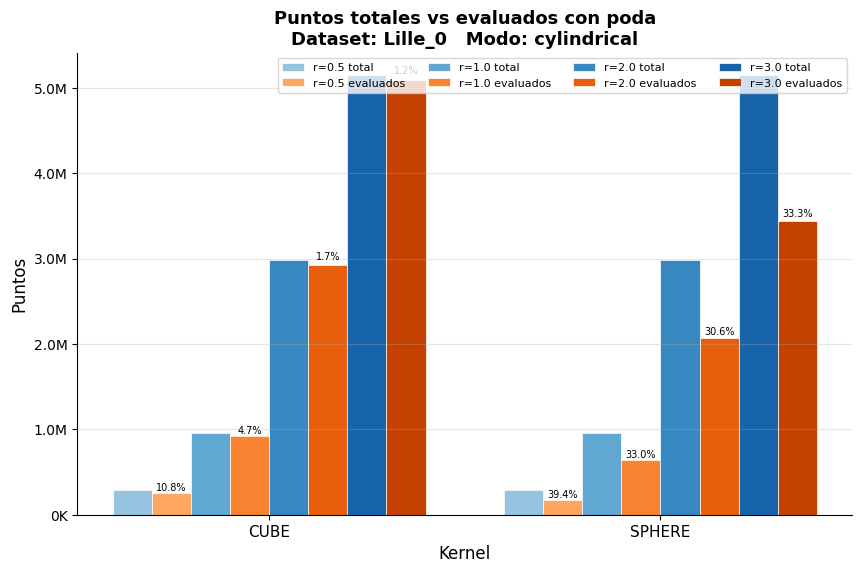

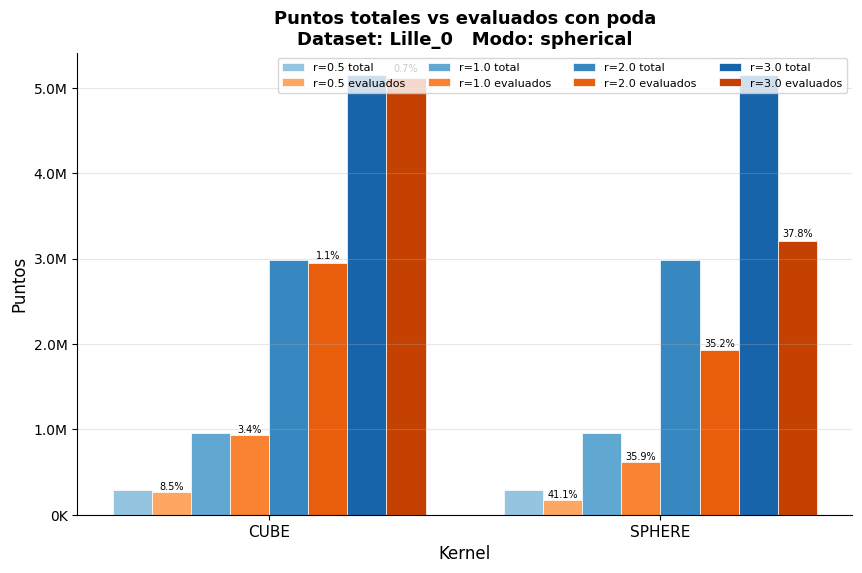

In [ ]:
if cesga:
    for log in Path('outv1.2/ranges').glob('*.log'):
        plot_pruning_points(log, save=True)
else:
    plot_pruning_points('logs/v1.1/ranges/Lille_0.log')

### Distribuciones de las podas

In [ ]:
def plot_pruning_distribution(csv_path: str, save: bool = False) -> None:
    df = pd.read_csv(csv_path)
    dataset_name = Path(csv_path).stem

    best = df.loc[df.groupby(['leaf', 'kernel', 'mode', 'radius'])['count'].idxmin()].copy()
    best['pct_pruned'] = (1 - best['count'] / best['total']) * 100

    # Hojas totales por kernel (antes de filtrar pct=0)
    total_leaves_by_kernel = (
        best.groupby(['mode', 'kernel', 'radius'])['leaf']
        .nunique()
        .reset_index()
        .rename(columns={'leaf': 'total_leaves'})
    )

    pruned = best[best['pct_pruned'] > 0]

    modes   = pruned['mode'].unique()
    kernels = sorted(pruned['kernel'].unique())
    radii   = sorted(pruned['radius'].unique())

    for mode in modes:
        df_mode  = pruned[pruned['mode'] == mode]
        df_total = total_leaves_by_kernel[total_leaves_by_kernel['mode'] == mode]

        n_kernels = len(kernels)
        fig, axes = plt.subplots(1, n_kernels,
                                  figsize=(5 * n_kernels, 8),
                                  sharey=True)
        if n_kernels == 1:
            axes = [axes]

        colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(radii)))

        for ax, kernel in zip(axes, kernels):
            df_k      = df_mode[df_mode['kernel'] == kernel]
            df_tot_k  = df_total[df_total['kernel'] == kernel].set_index('radius')

            data   = []
            labels = []

            for r in radii:
                d = df_k[df_k['radius'] == r]['pct_pruned'].values
                data.append(d)

                total_l  = df_tot_k.loc[r, 'total_leaves'] if r in df_tot_k.index else 0
                pruned_l = len(d)
                pct_l    = pruned_l / total_l * 100 if total_l > 0 else 0

                labels.append(
                    f'r={r}\n'
                    f'{pruned_l}/{total_l}\n'
                    f'({pct_l:.1f}% hojas)'
                )

            bp = ax.boxplot(data,
                            patch_artist=True,
                            medianprops=dict(color='white', linewidth=2),
                            whiskerprops=dict(linewidth=1.2),
                            capprops=dict(linewidth=1.2),
                            flierprops=dict(marker='o', markersize=2,
                                            alpha=0.3, linestyle='none'))

            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)

            for i, d in enumerate(data, start=1):
                if len(d) == 0:
                    continue
                median = np.median(d)
                mean   = np.mean(d)
                ax.text(i, median + 1, f'{median:.1f}%',
                        ha='center', va='bottom', fontsize=7,
                        color='white', fontweight='bold')
                ax.scatter(i, mean, marker='D', color='red',
                           s=20, zorder=5, label='media' if i == 1 else '')

            ax.set_xticks(range(1, len(radii) + 1))
            ax.set_xticklabels(labels, fontsize=8)
            ax.set_xlabel('Radio de búsqueda', fontsize=10)
            ax.set_title(kernel.upper(), fontsize=12, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)
            ax.spines[['top', 'right']].set_visible(False)
            ax.set_ylim(0, 105)

            if ax == axes[0]:
                ax.set_ylabel('% Puntos podados', fontsize=11)
                ax.legend(fontsize=8)

        fig.suptitle(
            f'Distribución del % de poda por hoja\n'
            f'Dataset: {dataset_name}   Modo: {mode}',
            fontsize=13, fontweight='bold', y=1.02)
        plt.show()
        if (save):
            out_path = Path(csv_path).parent / f'{dataset_name}_{mode}_pruning_distribution.png'
            plt.tight_layout()
            plt.savefig(out_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f'Guardado: {out_path}')

In [12]:
if cesga:
    for log in Path('outv1.2/ranges').glob('*.log'):
        plot_pruning_points(log, save=True)
else:
    plot_pruning_distribution('logs/v1.1/ranges/Lille_0.log')

Guardado: logs\v1.1\ranges\Lille_0_cylindrical_pruning_distribution.png
Guardado: logs\v1.1\ranges\Lille_0_spherical_pruning_distribution.png
